In [17]:

#Importing necessary Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [19]:
# import both the files using dataframe
act= pd.read_csv("C:/Users/91798/OneDrive/Desktop/bank & personal details/Data Anlytics/CapeStone/dailyActivity_merged_clean.csv")
sleep= pd.read_csv("C:/Users/91798/OneDrive/Desktop/bank & personal details/Data Anlytics/CapeStone/sleepDay_merged_clean.csv")


# Display 10 rows of the dataset

print(act.head(10))
print(sleep.head(10))



           Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  \
0  1503960366    4/12/2016       13162           8.50             8.50   
1  1503960366    4/13/2016       10735           6.97             6.97   
2  1503960366    4/14/2016       10460           6.74             6.74   
3  1503960366    4/15/2016        9762           6.28             6.28   
4  1503960366    4/16/2016       12669           8.16             8.16   
5  1503960366    4/17/2016        9705           6.48             6.48   
6  1503960366    4/18/2016       13019           8.59             8.59   
7  1503960366    4/19/2016       15506           9.88             9.88   
8  1503960366    4/20/2016       10544           6.68             6.68   
9  1503960366    4/21/2016        9819           6.34             6.34   

   LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  \
0                       0.0                1.88                      0.55   
1                       0.0    

In [20]:
###Lets take a peak into the data before cleaning:

print(act.info())
print(sleep.info())

###Check null values

emp_act= act.isnull().sum()
slp_act= sleep.isnull().sum()
print(emp_act)
print(slp_act)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    object 
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14  Calories  

In [21]:
###Summary statistics of both the dataset####												

act_stat= act[["TotalSteps", "TotalDistance", "TrackerDistance", "LoggedActivitiesDistance",
               "VeryActiveDistance", "ModeratelyActiveDistance", "LightActiveDistance",
               "SedentaryActiveDistance", "VeryActiveMinutes", "FairlyActiveMinutes", "LightlyActiveMinutes",
               "SedentaryMinutes", "Calories"]].describe()

slp_stat= sleep[["TotalSleepRecords", "TotalMinutesAsleep", "TotalTimeInBed"]].describe()

print(act_stat)
print(slp_stat)

###Identifying Duplicates###

print(sum(act.duplicated()))
print((sleep.duplicated()))

###Check for outliers using IQR only for the columns being used###

###Required Columns from Activity Dataset

# VeryActiveMinutes
# LightlyActiveMinutes
# SedentaryMinutes

###Checking for outliers in VeryActiveMinutes###


Q1_act = act['VeryActiveMinutes'].quantile(0.25)
Q3_act = act['VeryActiveMinutes'].quantile(0.75)
print(Q1_act)
print(Q3_act)

# Calculate IQR
IQR_act_min = Q3_act - Q1_act
print(IQR_act_min)

#Lower and Upper fence

lower_act_min= Q1_act-(1.5*IQR_act_min)
upper_act_min= Q3_act+(1.5*IQR_act_min)
print(lower_act_min)
print(upper_act_min)


###Checking for outliers in LightlyActiveMinutes

Q1_lig_act = act['LightlyActiveMinutes'].quantile(0.25)
Q3_lig_act = act['LightlyActiveMinutes'].quantile(0.75)

# Calculate IQR
IQR_lig_act = Q3_lig_act - Q1_lig_act
print(IQR_lig_act)

###Lower and Upper fence

lower_lig_act_min= Q1_lig_act-(1.5*IQR_lig_act)
upper_lig_act_min= Q3_lig_act+(1.5*IQR_lig_act)

lower_lig_act_min = max(0, lower_lig_act_min)

print(lower_lig_act_min)
print(upper_lig_act_min)


         TotalSteps  TotalDistance  TrackerDistance  LoggedActivitiesDistance  \
count    940.000000     940.000000       940.000000                940.000000   
mean    7637.910638       5.489702         5.475351                  0.108171   
std     5087.150742       3.924606         3.907276                  0.619897   
min        0.000000       0.000000         0.000000                  0.000000   
25%     3789.750000       2.620000         2.620000                  0.000000   
50%     7405.500000       5.245000         5.245000                  0.000000   
75%    10727.000000       7.712500         7.710000                  0.000000   
max    36019.000000      28.030001        28.030001                  4.942142   

       VeryActiveDistance  ModeratelyActiveDistance  LightActiveDistance  \
count          940.000000                940.000000           940.000000   
mean             1.502681                  0.567543             3.340819   
std              2.658941                 

In [23]:
print(act.columns.tolist())

['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance', 'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories']


729.75
1229.5
499.75
0
1979.125
 Statistics for VeryActiveMinutes 
count    940.000000
mean      21.164894
std       32.844803
min        0.000000
25%        0.000000
50%        4.000000
75%       32.000000
max      210.000000
Name: VeryActiveMinutes, dtype: float64

Top 10 highest values:
579    210
585    207
572    200
586    194
50     186
571    184
827    137
771    132
780    129
779    125
Name: VeryActiveMinutes, dtype: int64

Number of rows with VeryActiveMinutes > 200: 2
124.0
182.0
678.0
407.0
530.0
123.0
222.5
714.5
Number of outliers: 20
Percentage of outliers: 4.99 %

Outlier values:
 143    104
166    107
175    108
190    121
25     127
192    129
193    134
189    137
26     142
28     154
36     178
191    179
122    722
232    725
32     775
239    843
31     961
30     961
29     961
27     961
Name: TotalTimeInBed, dtype: int64
Original rows: 401
Rows after removing outliers: 381


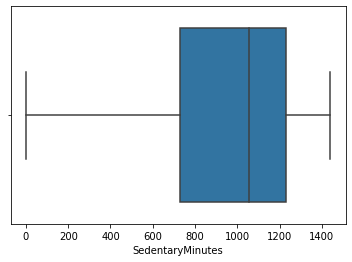

In [24]:
###Checking for outliers in SedentaryMinutes

Q1_sed = act['SedentaryMinutes'].quantile(0.25)
Q3_sed = act['SedentaryMinutes'].quantile(0.75)
print(Q1_sed)
print(Q3_sed)

# Calculate IQR
IQR_sed = Q3_sed - Q1_sed
print(IQR_sed)

#Lower and Upper fence

lower_sed= Q1_sed-(1.5*IQR_sed)
upper_sed= Q3_sed+(1.5*IQR_sed)

lower_sed = max(0, lower_sed)

print(lower_sed)
print(upper_sed)

###Checking for odd dataset

print(" Statistics for VeryActiveMinutes ")
print(act['VeryActiveMinutes'].describe())

print("\nTop 10 highest values:")
print(act['VeryActiveMinutes'].nlargest(10))

print("\nNumber of rows with VeryActiveMinutes > 200:", 
      (act['VeryActiveMinutes'] > 200).sum())

sns.boxplot(x=act['SedentaryMinutes'])

# Required columns for Sleep Dataset

# TotalMinutesAsleep
# TotalTimeInBed



Q1 = sleep['TotalMinutesAsleep'].quantile(0.25)
Q3 = sleep['TotalMinutesAsleep'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1
print(IQR)

#Lower and Upper fence

lower_sleep= Q1-(1.5*IQR)
upper_sleep= Q3+(1.5*IQR)
print(lower_sleep)
print(upper_sleep)

# TotalTimeInBed


Q1_tim_bed = sleep['TotalTimeInBed'].quantile(0.25)
Q3_tim_bed = sleep['TotalTimeInBed'].quantile(0.75)
print(Q1_tim_bed)
print(Q3_tim_bed)

# Calculate IQR
IQR_tim_bed = Q3_tim_bed - Q1_tim_bed
print(IQR_tim_bed)

#Lower and Upper fence

lower_sleep_tim_bed= Q1_tim_bed-(1.5*IQR_tim_bed)
upper_sleep_tim_bed= Q3_tim_bed+(1.5*IQR_tim_bed)
print(lower_sleep_tim_bed)
print(upper_sleep_tim_bed)

# Identifying the outliers

outliers = sleep[(sleep['TotalTimeInBed'] < 222.5) | (sleep['TotalTimeInBed'] > 714.5)]

print("Number of outliers:", len(outliers))
print("Percentage of outliers:", round(len(outliers)/len(sleep)*100, 2), "%")
print("\nOutlier values:\n", outliers['TotalTimeInBed'].sort_values())

#Cleaning the outliers

sleep_clean = sleep[(sleep['TotalTimeInBed'] >= 222.5) & 
                    (sleep['TotalTimeInBed'] <= 714.5)].copy()

print("Original rows:", len(sleep))
print("Rows after removing outliers:", len(sleep_clean))


In [27]:
###Checking for outlier after removing them

Q1_tim_bed_cln = sleep_clean['TotalTimeInBed'].quantile(0.25)
Q3_tim_bed_cln = sleep_clean['TotalTimeInBed'].quantile(0.75)
print(Q1_tim_bed_cln)
print(Q3_tim_bed_cln)

# Calculate IQR
IQR_tim_bed_cln = Q3_tim_bed_cln - Q1_tim_bed_cln
print(IQR_tim_bed_cln)

#Lower and Upper fence

lower_sleep_tim_bed_cln= Q1_tim_bed_cln-(1.5*IQR_tim_bed_cln)
upper_sleep_tim_bed_cln= Q3_tim_bed_cln+(1.5*IQR_tim_bed_cln)
print(lower_sleep_tim_bed_cln)
print(upper_sleep_tim_bed_cln)


outliers_new = sleep_clean[(sleep_clean['TotalTimeInBed'] < 222.5) | (sleep_clean['TotalTimeInBed'] > 714.5)]

print("Number of outliers:", len(outliers_new))
print("Percentage of outliers:", round(len(outliers_new)/len(sleep_clean)*100, 2), "%")
print("\nOutlier values:\n", outliers_new['TotalTimeInBed'].sort_values())


414.0
526.0
112.0
246.0
694.0
Number of outliers: 0
Percentage of outliers: 0.0 %

Outlier values:
 Series([], Name: TotalTimeInBed, dtype: int64)


In [28]:
#Standardizing the columns

act.columns = act.columns.str.lower()
sleep_clean.columns = sleep_clean.columns.str.lower()


#print(sleep_clean.describe())

act.rename(columns={'activitydate': 'date'}, inplace=True)
sleep_clean.rename(columns={'sleepday_date': 'date'}, inplace=True)


# Creating a new column

sleep_clean[('sleepefficiency')]= sleep_clean['totalminutesasleep'] / sleep_clean['totaltimeinbed']
sleep_clean[('sleepefficiency')]= sleep_clean[('sleepefficiency')].round(2)


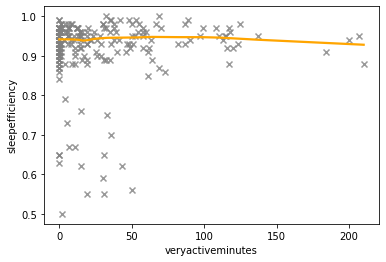

In [29]:
#### Analysis

#How do different activity intensity levels (very active, lightly active, sedentary) impact sleep duration and quality?


# Createing a grpah on identifying the relation between the being very active and its affect on the spleep efficiency

merged = act.merge(
    sleep_clean,
    on=['id', 'date']
)


sns.regplot(x='veryactiveminutes', y='sleepefficiency', 
            scatter_kws={"color": "Grey"}, line_kws={"color": "Orange"}, marker= "x", lowess= True, data=merged)
plt.show()


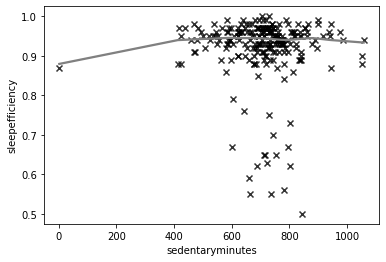

In [30]:
#Createing a grpah on identifying the relation between the being Sedentary active and its affect on the spleep efficiency


sns.regplot(x='sedentaryminutes', y='sleepefficiency', 
            scatter_kws={"color": "Black"}, line_kws={"color": "Grey"}, marker= "x", lowess= True, data=merged)
plt.show()



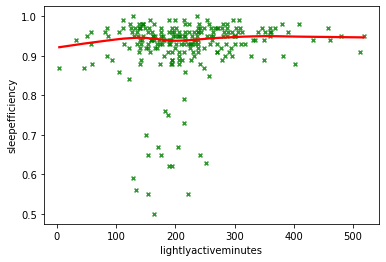

In [10]:
#Createing a grpah on identifying the relation between the being Lightly active and its affect on the spleep efficiency

sns.regplot(x='lightlyactiveminutes' , y='sleepefficiency', 
            scatter_kws={'s': 15, "color": "Green"}, line_kws={"color": "Red"}, 
            marker= "x", lowess= True, data=merged)
plt.show()


daytype
Weekday    8327.924602
Weekend    9576.643750
Name: totalsteps, dtype: float64


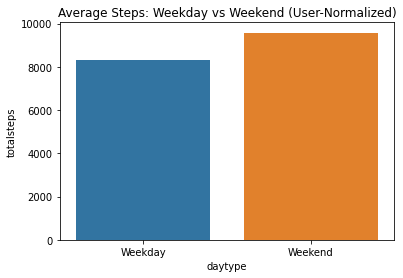

id                                   int64
date                        datetime64[ns]
totalsteps                           int64
totaldistance                      float64
trackerdistance                    float64
loggedactivitiesdistance           float64
veryactivedistance                 float64
moderatelyactivedistance           float64
lightactivedistance                float64
sedentaryactivedistance            float64
veryactiveminutes                    int64
fairlyactiveminutes                  int64
lightlyactiveminutes                 int64
sedentaryminutes                     int64
calories                             int64
sleepday_time                       object
totalsleeprecords                    int64
totalminutesasleep                   int64
totaltimeinbed                       int64
sleepefficiency                    float64
daytype                             object
dtype: object


In [33]:
# Ensure date column is datetime
merged['date'] = pd.to_datetime(merged['date'])

# Create weekday/weekend column
merged['daytype'] = merged['date'].dt.dayofweek.apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)
## We added and addition column to out merged dataset called "daytype" to biforcate between weekdays and weekends

act_sum = merged.groupby(['id', 'daytype'])['totalsteps'].mean().groupby('daytype').mean()
print(act_sum)

#plotting the grpah

act_sum = act_sum.reset_index()
sns.barplot(x='daytype', y='totalsteps', data=act_sum)
plt.title('Average Steps: Weekday vs Weekend (User-Normalized)')
plt.show()

print(merged.dtypes)

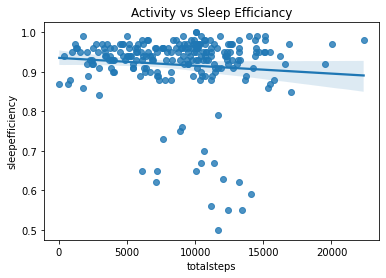

In [13]:
# Is there a relationship between Activuty level and Sleep Duration?

sns.regplot(x='totalsteps', y='sleepefficiency', data=merged)
plt.title('Activity vs Sleep Efficiancy')
plt.show()